In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# /scratch/suyuelyu/deimm/results/probe_taxon/class_ce_mmap/confusion_class.npz
data = np.load("/scratch/suyuelyu/deimm/results/probe_taxon/class_ce_mmap/confusion_class.npz")

In [5]:
data_class = data["classes"]
data_val = data["val"]
data_test = data["test"]

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_from_raw_matrix(cm_raw, class_names=None):
    """
    Converts an unnormalized confusion matrix to a normalized one and plots it.
    """
    # Ensure it is a numpy array
    cm_raw = np.array(cm_raw)

    # 1. Normalize by row (Recall)
    # keepdims=True ensures the division broadcasts correctly across the 17 columns
    row_sums = cm_raw.sum(axis=1, keepdims=True)

    # Avoid division by zero in case a class has exactly 0 true instances
    cm_normalized = np.divide(
        cm_raw.astype(float),
        row_sums,
        out=np.zeros_like(cm_raw, dtype=float),
        where=row_sums != 0,
    )

    # 2. Plot the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=False,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Proportion of True Class (Recall)"},
    )

    plt.title("Row-Normalized Confusion Matrix", fontsize=16, pad=15)
    plt.xlabel("Predicted Class", fontsize=14, labelpad=10)
    plt.ylabel("True Class", fontsize=14, labelpad=10)

    # plt.xticks(rotation=45, ha="right")
    # plt.yticks(rotation=0)
    # hide the ticks and labels for a cleaner look
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    plt.show()


# Example usage if you have your matrix stored in a variable called 'my_raw_matrix':
# plot_from_raw_matrix(my_raw_matrix, class_names=my_17_categories)

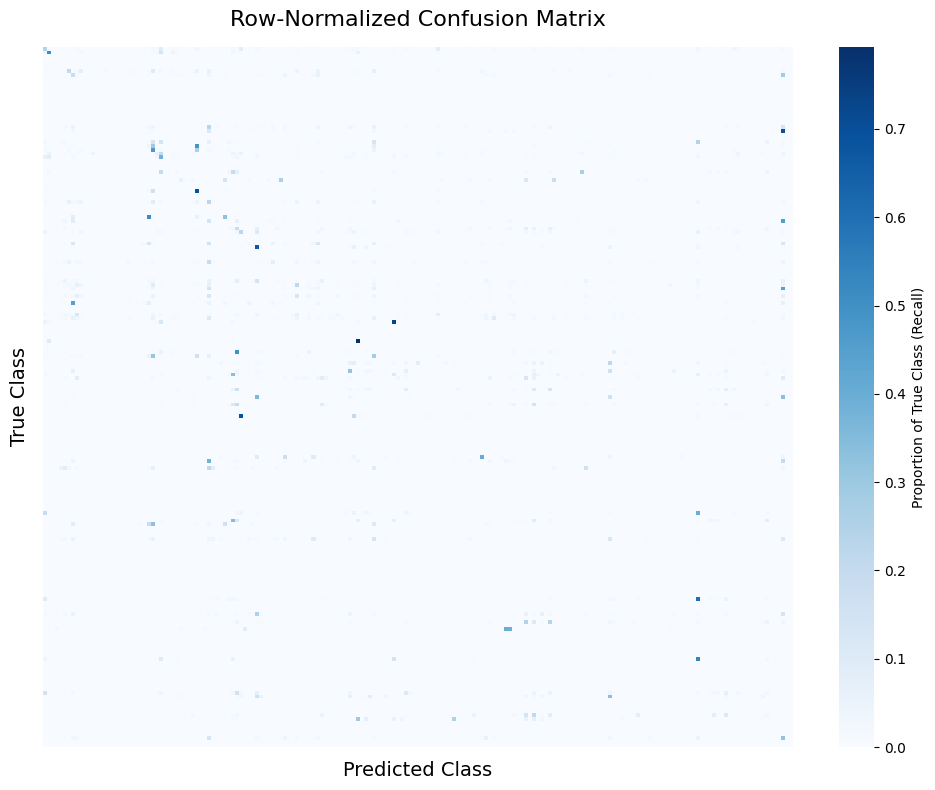

In [27]:
plot_from_raw_matrix(data_test, class_names=data_class)

In [28]:
import numpy as np
import pandas as pd


def analyze_large_confusion_matrix(cm_raw, class_names=None, top_k=15):
    """
    Analyzes an unnormalized confusion matrix for a large number of classes.

    Args:
        cm_raw: 2D array-like unnormalized confusion matrix.
        class_names: Optional list of strings for class names.
        top_k: Number of top results to return for hotspots and bias.
    """
    cm = np.array(cm_raw)
    n_classes = cm.shape[0]

    if class_names is None:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    # Calculate row sums (Actual instances) and column sums (Predicted instances)
    true_counts = cm.sum(axis=1)
    pred_counts = cm.sum(axis=0)

    # ---------------------------------------------------------
    # 1. The Diagonal: Success / Recall Analysis
    # ---------------------------------------------------------
    # Suppress divide-by-zero warnings for classes with 0 true samples
    with np.errstate(divide="ignore", invalid="ignore"):
        recall = np.diag(cm) / true_counts
        recall = np.nan_to_num(recall, nan=0.0)  # Convert NaNs to 0

    recall_df = pd.DataFrame(
        {
            "Class": class_names,
            "True_Count": true_counts,
            "Correctly_Predicted": np.diag(cm),
            "Recall": recall,
        }
    ).sort_values(by="Recall", ascending=False)

    # ---------------------------------------------------------
    # 2. Off-Diagonal Hotspots: Top Confusions
    # ---------------------------------------------------------
    # Create a copy and zero out the diagonal to isolate errors
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)

    # Extract coordinates of all non-zero errors
    row_idx, col_idx = np.nonzero(cm_errors)

    confusions = []
    for r, c in zip(row_idx, col_idx):
        error_count = cm_errors[r, c]
        true_total = true_counts[r]
        pct_of_true = (error_count / true_total) * 100 if true_total > 0 else 0

        confusions.append(
            {
                "True_Class": class_names[r],
                "Predicted_Class": class_names[c],
                "Error_Count": error_count,
                "%_of_True_Class": pct_of_true,
            }
        )

    hotspots_df = pd.DataFrame(confusions).sort_values(
        by="Error_Count", ascending=False
    )

    # ---------------------------------------------------------
    # 3. Diagnosing Model Bias: Over/Under-Prediction
    # ---------------------------------------------------------
    # Bias Ratio = Predicted / True.
    # > 1 means the model over-predicts it. < 1 means the model under-predicts it.
    with np.errstate(divide="ignore", invalid="ignore"):
        bias_ratio = pred_counts / true_counts
        bias_ratio = np.nan_to_num(bias_ratio, nan=0.0)

    bias_df = pd.DataFrame(
        {
            "Class": class_names,
            "True_Count": true_counts,
            "Predicted_Count": pred_counts,
            "Net_Difference": pred_counts - true_counts,
            "Bias_Ratio": bias_ratio,
        }
    )

    # Filter out classes with 0 true samples to avoid skewed ratios
    valid_bias_df = bias_df[bias_df["True_Count"] > 0]
    over_predicted = valid_bias_df.sort_values(by="Bias_Ratio", ascending=False)
    under_predicted = valid_bias_df.sort_values(by="Bias_Ratio", ascending=True)

    print(f"--- Top {top_k} Off-Diagonal Hotspots (Worst Confusions) ---")
    print(hotspots_df.head(top_k).to_string(index=False))
    print("\n" + "=" * 60 + "\n")

    print(f"--- Top {top_k} Over-Predicted Classes ('Catch-Alls') ---")
    print(over_predicted.head(top_k).to_string(index=False))
    print("\n" + "=" * 60 + "\n")

    print(f"--- Top {top_k} Under-Predicted Classes ('Invisible Classes') ---")
    print(under_predicted.head(top_k).to_string(index=False))

    return recall_df, hotspots_df, bias_df


# Example Execution:
# recall, hotspots, bias = analyze_large_confusion_matrix(my_187_class_matrix)

In [29]:
recall_df, hotspots_df, bias_df = analyze_large_confusion_matrix(data_test, class_names=data_class)

--- Top 15 Off-Diagonal Hotspots (Worst Confusions) ---
 True_Class  Predicted_Class  Error_Count  %_of_True_Class
      40674             8782        12879        16.966815
       3398             8782         6779         9.857209
     186623             8782         6674        31.189831
      50557             8782         6209         9.138946
     119089            50557         5980        19.351498
       4891          3239874         5438        29.301148
       3398             5653         5323         7.740069
       3398           186623         4515         6.565172
      50557             3398         4173         6.142184
       3398            50557         3844         5.589484
      50557           186623         3794         5.584339
     186623            40674         3535        16.520236
       3398            40674         3484         5.066015
      50557             5653         3292         4.845452
       3398           147554         3263         4.744664


In [30]:
import pickle
# /scratch/suyuelyu/deimm/results/probe_taxon/class_ce_mmap/probe_class_data.pkl
with open("/scratch/suyuelyu/deimm/results/probe_taxon/class_ce_mmap/probe_class_data.pkl", "rb") as f:
    class_probe_data = pickle.load(f)


In [ ]:
classes = class_probe_data["classes"]
pos_per_class = class_probe_data["pos_per_class"]
class_to_pos = dict(zip(classes, pos_per_class))

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def analyze_training_bias_correlation(bias_df, train_counts_dict):
    """
    Checks if over/under-prediction is correlated with training sample counts.

    Args:
        bias_df: The bias DataFrame generated from our previous function.
        train_counts_dict: A dictionary mapping {'Class_Name': training_count}.
    """
    # 1. Convert dictionary to a pandas DataFrame for easy merging
    train_df = pd.DataFrame(
        list(train_counts_dict.items()), columns=["Class", "Train_Count"]
    )

    # 2. Merge the training counts with your bias metrics
    # This aligns the training counts with the Bias_Ratio for each class
    merged_df = pd.merge(bias_df, train_df, on="Class", how="inner")

    # Drop classes with zero true test samples to avoid infinity/NaN bias ratios
    valid_df = merged_df[merged_df["True_Count"] > 0].copy()

    # 3. Calculate Spearman correlation
    # (Spearman is best for skewed count data in biology)
    correlation = valid_df["Train_Count"].corr(
        valid_df["Bias_Ratio"], method="spearman"
    )

    print(f"Spearman Correlation between Train Count and Bias Ratio: {correlation:.3f}")

    # 4. Plot the relationship
    plt.figure(figsize=(10, 6))

    # Using a log scale for the x-axis is highly recommended for biological datasets
    sns.regplot(
        data=valid_df,
        x="Train_Count",
        y="Bias_Ratio",
        scatter_kws={"alpha": 0.6, "edgecolor": "w"},
        line_kws={"color": "red"},
        logx=True,
    )  # Assumes you might have an order of magnitude difference in counts

    plt.axhline(
        1.0, color="black", linestyle="--", label="Perfect Balance (Ratio = 1.0)"
    )

    plt.title(
        f"Does Training Size Drive Prediction Bias? (r = {correlation:.3f})",
        fontsize=14,
    )
    plt.xlabel("Number of Samples in Training Set", fontsize=12)
    plt.ylabel("Prediction Bias Ratio (Predicted / Actual)", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return valid_df


# Example Execution:
# correlation_df = analyze_training_bias_correlation(bias_df, my_training_dictionary)#

Spearman Correlation between Train Count and Bias Ratio: -0.190


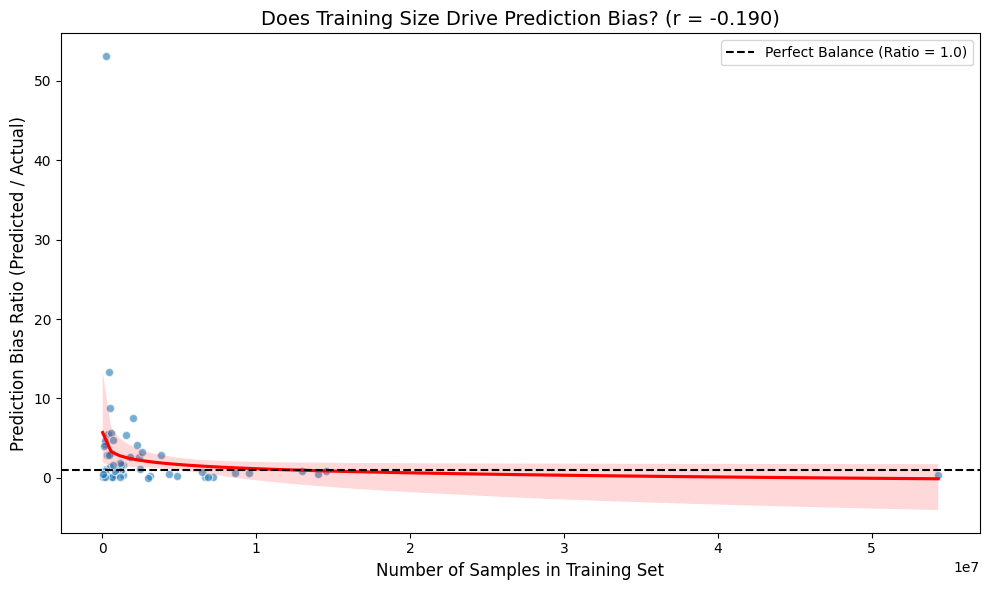

In [34]:
correlation_df = analyze_training_bias_correlation(bias_df, class_to_pos)